In [1]:
import pandas as pd
import matplotlib.pyplot as plt

cols = ["unit_id", "cycle", "op1", "op2", "op3"] + [f"s{i}" for i in range(1, 22)]
train = pd.read_csv("../data/raw/CMAPSSData/train_FD001.txt",
                    sep=r"\s+", header=None, names=cols)

print(train.shape)                      # 행·열 수
print(train["unit_id"].nunique())       # 엔진 수
life = train.groupby("unit_id")["cycle"].max()
print(life.describe()) 

(20631, 26)
100
count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64


In [2]:
stats = train.describe().T[["mean", "std", "min", "max"]]
print(stats.sort_values("std"))

                mean           std        min        max
s1        518.670000  0.000000e+00   518.6700   518.6700
op3       100.000000  0.000000e+00   100.0000   100.0000
s10         1.300000  0.000000e+00     1.3000     1.3000
s18      2388.000000  0.000000e+00  2388.0000  2388.0000
s19       100.000000  0.000000e+00   100.0000   100.0000
s16         0.030000  3.469531e-18     0.0300     0.0300
s5         14.620000  5.329200e-15    14.6200    14.6200
op2         0.000002  2.930621e-04    -0.0006     0.0006
s6         21.609803  1.388985e-03    21.6000    21.6100
op1        -0.000009  2.187313e-03    -0.0087     0.0087
s15         8.442146  3.750504e-02     8.3249     8.5848
s8       2388.096652  7.098548e-02  2387.9000  2388.5600
s13      2388.096152  7.191892e-02  2387.8800  2388.5600
s21        23.289705  1.082509e-01    22.8942    23.6184
s20        38.816271  1.807464e-01    38.1400    39.4300
s11        47.541168  2.670874e-01    46.8500    48.5300
s2        642.680934  5.000533e

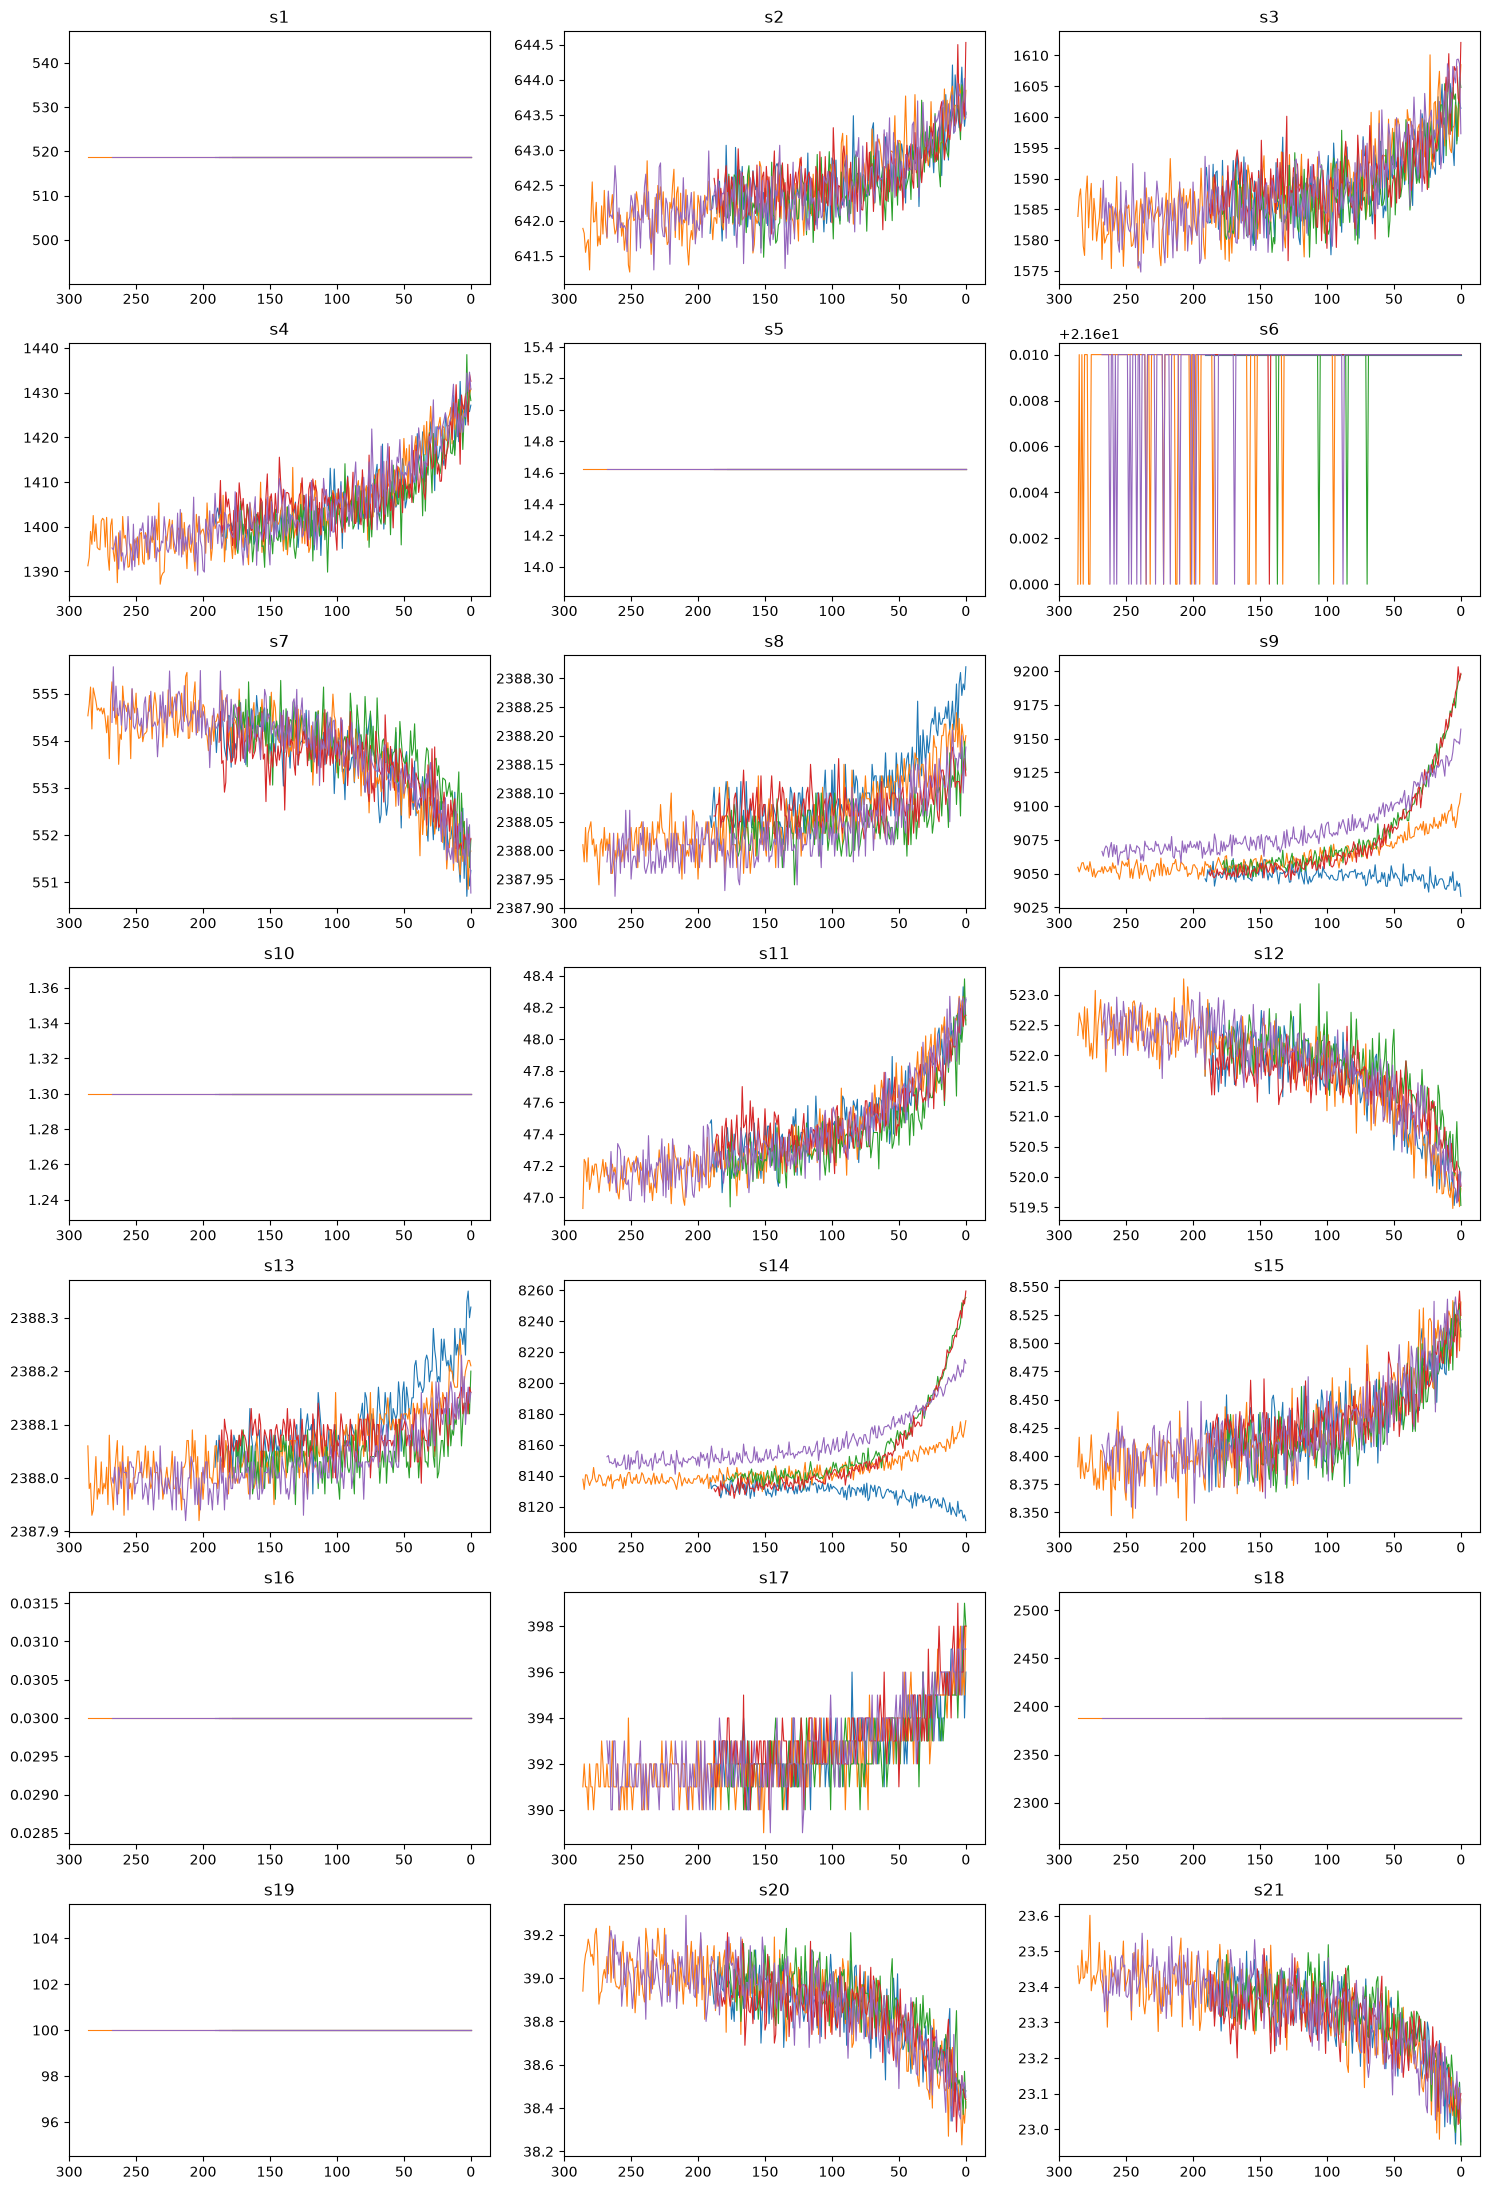

In [3]:
train["rul"] = train.groupby("unit_id")["cycle"].transform("max") - train["cycle"]

sensors = [f"s{i}" for i in range(1, 22)]
fig, axes = plt.subplots(7, 3, figsize=(15, 22))
for ax, s in zip(axes.flat, sensors):
    for u in [1, 2, 3, 4, 5]:
        d = train[train["unit_id"] == u]
        ax.plot(d["rul"], d[s], linewidth=0.8)
    ax.invert_xaxis()      # 왼쪽이 정상, 오른쪽이 고장 직전
    ax.set_title(s)
plt.tight_layout()

In [4]:
corr = train[sensors + ["rul"]].corr()["rul"].drop("rul")
print(corr.sort_values())

s11   -0.696228
s4    -0.678948
s15   -0.642667
s2    -0.606484
s17   -0.606154
s3    -0.584520
s8    -0.563968
s13   -0.562569
s9    -0.390102
s14   -0.306769
s6    -0.128348
s20    0.629428
s21    0.635662
s7     0.657223
s12    0.671983
s1          NaN
s5          NaN
s10         NaN
s16         NaN
s18         NaN
s19         NaN
Name: rul, dtype: float64
